# 센서 데이터 도착 주기 분석

이 노트북은 `pipeline_output/organized_by_sensor/` 디렉토리에 있는 센서 데이터들의 도착 주기 분포를 분석합니다.

## 분석 목표
- 각 센서별 데이터 도착 간격 계산
- 도착 주기의 통계적 특성 분석
- 이상치 및 패턴 식별

In [66]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 색상 팔레트 설정
sns.set_palette("husl")

print("라이브러리 임포트 완료")

라이브러리 임포트 완료


In [78]:
def load_sensor_data(file_path):
    """센서 데이터 파일을 로드하고 DataFrame으로 변환"""
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    df = pd.DataFrame(data)
    if 'ts' in df.columns:
        # ISO8601 형식으로 타임스탬프 파싱 (마이크로초 유무와 상관없이)
        df['timestamp'] = pd.to_datetime(df['ts'], format='ISO8601')
        df = df.sort_values('timestamp').reset_index(drop=True)
    
    return df

def calculate_arrival_intervals(df):
    """데이터 도착 간격(초) 계산"""
    if len(df) < 2:
        return np.array([])
    
    timestamps = df['timestamp'].values
    intervals = np.diff(timestamps).astype('timedelta64[s]').astype(float)
    
    return intervals

def analyze_sensor_intervals(intervals):
    """도착 간격에 대한 통계 분석"""
    if len(intervals) == 0:
        return {}
    
    return {
        'count': len(intervals),
        'mean_seconds': np.mean(intervals),
        'std_seconds': np.std(intervals),
        'min_seconds': np.min(intervals),
        'max_seconds': np.max(intervals),
        'median_seconds': np.median(intervals),
        'q25_seconds': np.percentile(intervals, 25),
        'q75_seconds': np.percentile(intervals, 75)
    }

print("분석 함수 정의 완료")

분석 함수 정의 완료


In [79]:
def load_sensor_data(file_path):
    """센서 데이터 파일을 로드하고 DataFrame으로 변환"""
    file_path_str = str(file_path)
    if file_path_str.endswith(".json"):
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            df = pd.DataFrame(data)
    elif file_path_str.endswith(".csv"):
        df = pd.read_csv(file_path)
    
    if 'ts' in df.columns:
        df['timestamp'] = pd.to_datetime(df['ts'])
        df = df.sort_values('timestamp').reset_index(drop=True)
    
    return df

def calculate_arrival_intervals(df):
    """데이터 도착 간격(초) 계산"""
    if len(df) < 2:
        return np.array([])
    
    timestamps = df['timestamp'].values
    intervals = np.diff(timestamps).astype('timedelta64[s]').astype(float)
    
    return intervals

def analyze_sensor_intervals(intervals):
    """도착 간격에 대한 통계 분석"""
    if len(intervals) == 0:
        return {}
    
    return {
        'count': len(intervals),
        'mean_seconds': np.mean(intervals),
        'std_seconds': np.std(intervals),
        'min_seconds': np.min(intervals),
        'max_seconds': np.max(intervals),
        'median_seconds': np.median(intervals),
        'q25_seconds': np.percentile(intervals, 25),
        'q75_seconds': np.percentile(intervals, 75)
    }

print("분석 함수 정의 완료")

분석 함수 정의 완료


In [80]:
# 데이터 로드 및 전처리 함수
def load_and_preprocess_data(file_path):
    """JSON 파일 로드 및 전처리"""
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        if not data:
            return None
            
        df = pd.DataFrame(data)
        
        # 타임스탬프 변환 - 여러 포맷 지원
        def parse_timestamp(ts):
            if pd.isna(ts):
                return None
            
            # 이미 datetime 객체인 경우
            if isinstance(ts, pd.Timestamp):
                return ts
            
            # 문자열인 경우 여러 포맷 시도
            if isinstance(ts, str):
                formats_to_try = [
                    "%Y-%m-%d %H:%M:%S.%f%z",  # 마이크로초 + 타임존
                    "%Y-%m-%d %H:%M:%S%z",      # 초 + 타임존 (마이크로초 없음)
                    "%Y-%m-%d %H:%M:%S.%f",     # 마이크로초 (타임존 없음)
                    "%Y-%m-%d %H:%M:%S",        # 초 (타임존 없음)
                ]
                
                for fmt in formats_to_try:
                    try:
                        return pd.to_datetime(ts, format=fmt)
                    except (ValueError, TypeError):
                        continue
                
                # ISO8601 포맷으로 시도
                try:
                    return pd.to_datetime(ts, format='ISO8601')
                except (ValueError, TypeError):
                    pass
                
                # 마지막으로 pandas 자동 파싱 시도
                try:
                    return pd.to_datetime(ts)
                except (ValueError, TypeError):
                    pass
            
            print(f"타임스탬프 파싱 실패: {ts}")
            return None
        
        # 타임스탬프 컬럼 변환
        if 'timestamp' in df.columns:
            df['timestamp'] = df['timestamp'].apply(parse_timestamp)
            # 파싱 실패한 데이터 제거
            df = df.dropna(subset=['timestamp'])
        else:
            print(f"'timestamp' 컬럼이 없습니다: {file_path}")
            return None
            
        return df
        
    except Exception as e:
        print(f"파일 로드 오류 {file_path}: {e}")
        return None

In [81]:
# 도착 주기 계산 함수
def calculate_arrival_intervals(df):
    """데이터 도착 주기(초) 계산"""
    if len(df) < 2:
        return []
    
    # 타임스탬프로 정렬
    df_sorted = df.sort_values('timestamp')
    
    # 연속된 데이터 포인트 간의 시간 간격 계산 (초 단위)
    intervals = []
    for i in range(1, len(df_sorted)):
        interval = (df_sorted.iloc[i]['timestamp'] - df_sorted.iloc[i-1]['timestamp']).total_seconds()
        intervals.append(interval)
    
    return intervals

# 도착 주기 분석 함수
def analyze_arrival_intervals(df):
    """도착 주기 통계 분석"""
    intervals = calculate_arrival_intervals(df)
    
    if not intervals:
        return {}
    
    return {
        'mean_interval': np.mean(intervals),
        'median_interval': np.median(intervals),
        'std_interval': np.std(intervals),
        'min_interval': np.min(intervals),
        'max_interval': np.max(intervals),
        'count': len(intervals),
        'intervals': intervals  # 원본 간격 데이터도 저장
    }

In [82]:
# 모든 센서 데이터 로드 및 도착 주기 분석
all_sensor_data = {}
interval_metadata = []

print("데이터 로드 및 도착 주기 분석 시작...")

for sensor_name, files in sensor_files.items():
    print(f"\n{sensor_name} 분석 중...")
    sensor_data = {}
    
    for file_path in files:
        file_name = os.path.basename(file_path)
        print(f"  파일: {file_name}")
        
        df = load_and_preprocess_data(file_path)
        if df is not None and len(df) > 0:
            # 도착 주기 분석
            analysis = analyze_arrival_intervals(df)
            if analysis:
                sensor_data[file_name] = df
                
                # 메타데이터 수집
                for interval in analysis['intervals']:
                    interval_metadata.append({
                        'sensor_category': sensor_name,
                        'file_name': file_name,
                        'interval_seconds': interval
                    })
                
                print(f"    데이터 포인트: {len(df):,}")
                print(f"    평균 도착 주기: {analysis['mean_interval']:.2f}초")
            else:
                print(f"    도착 주기 분석 실패")
        else:
            print(f"    데이터 로드 실패")
    
    if sensor_data:
        all_sensor_data[sensor_name] = sensor_data

print(f"\n총 처리된 센서 카테고리: {len(all_sensor_data)}개")
print(f"총 도착 간격 데이터: {len(interval_metadata):,}개")

데이터 로드 및 도착 주기 분석 시작...


NameError: name 'sensor_files' is not defined

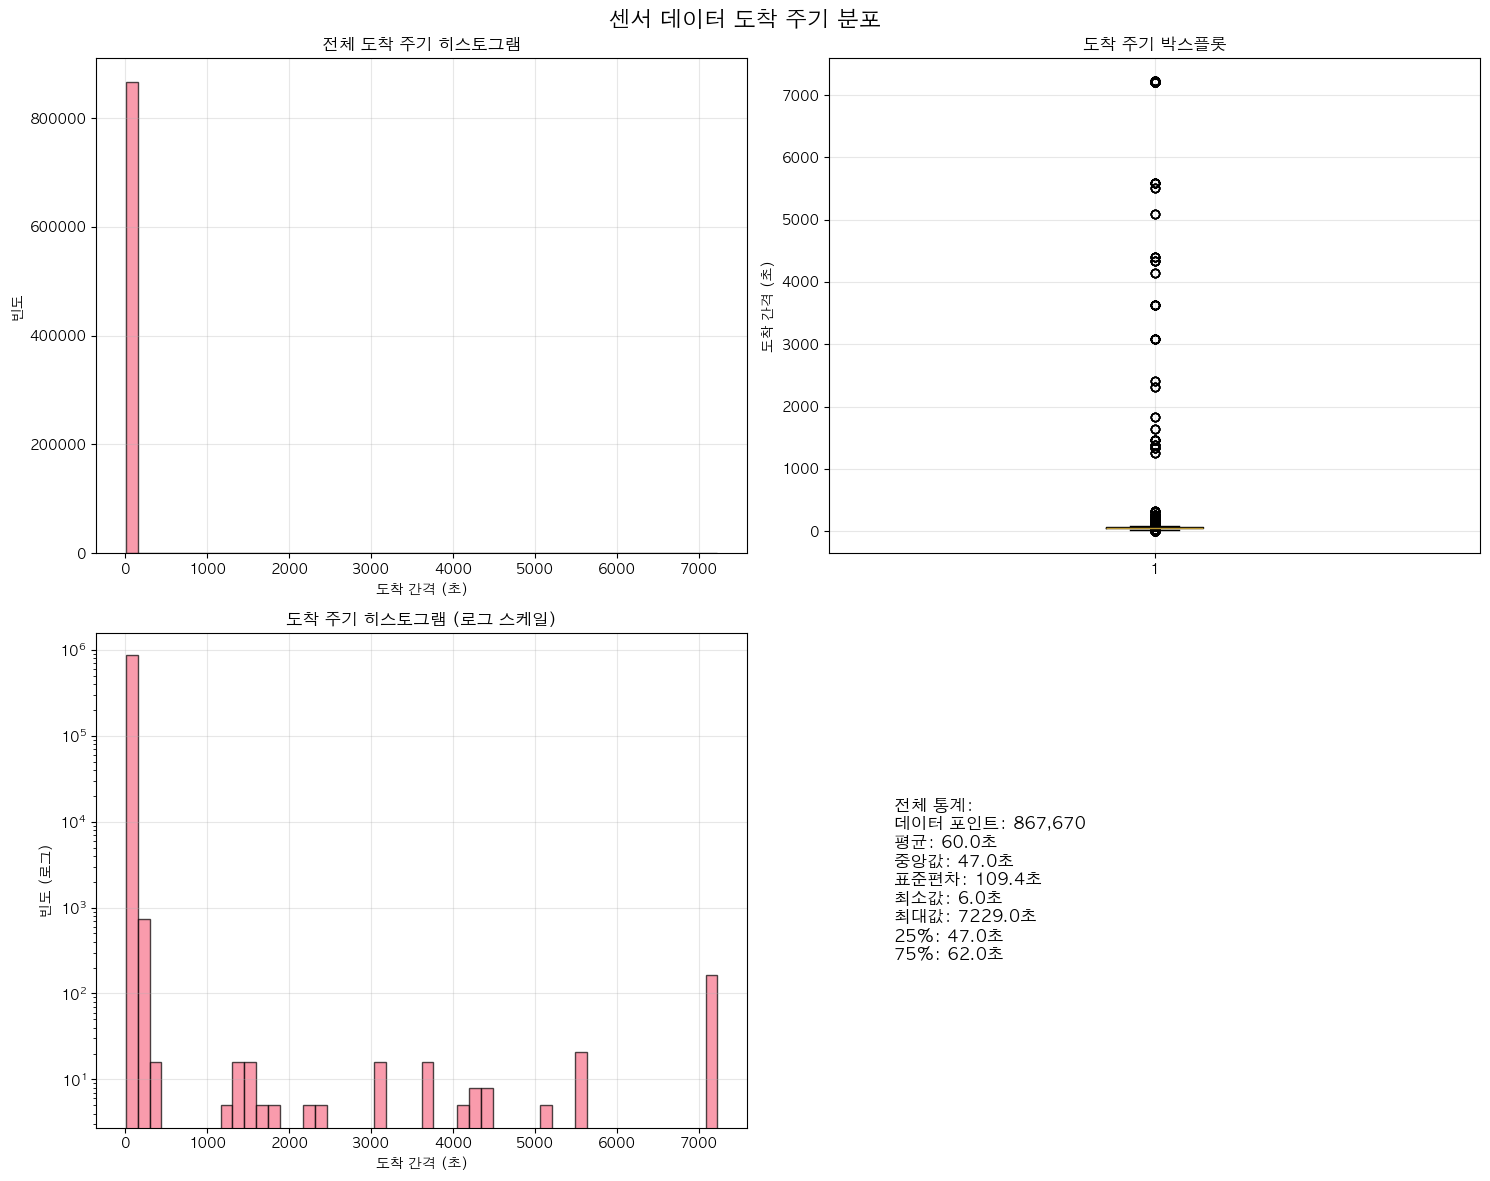

In [ ]:
# 도착 주기 통계 분석
intervals_df = pd.DataFrame(interval_metadata)

if len(intervals_df) > 0:
    print(f"전체 도착 간격 데이터: {len(intervals_df):,}개")
    print(f"시간 범위: {intervals_df['interval_seconds'].min():.1f}초 ~ {intervals_df['interval_seconds'].max():.1f}초")
    print(f"전체 평균: {intervals_df['interval_seconds'].mean():.2f}초")
    print(f"전체 중앙값: {intervals_df['interval_seconds'].median():.2f}초")
    print(f"전체 표준편차: {intervals_df['interval_seconds'].std():.2f}초")
else:
    print("도착 간격 데이터가 없습니다.")

In [ ]:
# 센서 카테고리별 도착 주기 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('센서 카테고리별 도착 주기 분석', fontsize=16, fontweight='bold')

# 1. 평균 도착 주기 바 차트
mean_intervals = category_stats['평균'].sort_values()
axes[0,0].barh(range(len(mean_intervals)), mean_intervals.values, color='skyblue', edgecolor='navy')
axes[0,0].set_title('센서 카테고리별 평균 도착 주기')
axes[0,0].set_xlabel('평균 도착 간격 (초)')
axes[0,0].set_yticks(range(len(mean_intervals)))
axes[0,0].set_yticklabels(mean_intervals.index, fontsize=10)
axes[0,0].grid(True, alpha=0.3)

# 값 표시
for i, v in enumerate(mean_intervals.values):
    axes[0,0].text(v + 1, i, f'{v:.1f}초', va='center', fontweight='bold')

# 2. 박스플롯 (카테고리별)
boxplot_data = []
boxplot_labels = []

for sensor_category in intervals_df['sensor_category'].unique():
    data = intervals_df[intervals_df['sensor_category'] == sensor_category]['interval_seconds'].values
    # 이상치 제거를 위해 99% 백분위수까지의 데이터만 사용
    data_filtered = data[data <= np.percentile(data, 99)]
    boxplot_data.append(data_filtered)
    boxplot_labels.append(sensor_category.replace('AGS_Green_', '').replace('_', '\n'))

bp = axes[0,1].boxplot(boxplot_data, labels=boxplot_labels, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
axes[0,1].set_title('센서 카테고리별 도착 주기 분포')
axes[0,1].set_ylabel('도착 간격 (초)')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(True, alpha=0.3)

# 3. 히스토그램 (주요 카테고리)
motor_data = intervals_df[intervals_df['sensor_category'].str.contains('모터제어')]['interval_seconds']
sensor_data = intervals_df[~intervals_df['sensor_category'].str.contains('모터제어')]['interval_seconds']

axes[1,0].hist([motor_data, sensor_data], bins=50, alpha=0.7, 
               label=['모터제어 센서', '환경 센서'], color=['red', 'blue'], edgecolor='black')
axes[1,0].set_title('모터제어 vs 환경 센서 도착 주기 분포')
axes[1,0].set_xlabel('도착 간격 (초)')
axes[1,0].set_ylabel('빈도')
axes[1,0].legend()
axes[1,0].set_xlim(0, 300)  # 5분 이내 데이터에 집중
axes[1,0].grid(True, alpha=0.3)

# 4. 통계 요약 테이블
summary_text = "주요 통계 요약:\n\n"
for idx, (category, stats) in enumerate(category_stats.iterrows()):
    if idx < 3:  # 상위 3개만 표시
        summary_text += f"{category.replace('AGS_Green_', '')}:\n"
        summary_text += f"  평균: {stats['평균']:.1f}초\n"
        summary_text += f"  중앙값: {stats['중앙값']:.1f}초\n"
        summary_text += f"  최빈값: {stats['최빈값']:.1f}초\n"
        summary_text += f"  데이터수: {stats['데이터수']:,}개\n\n"

axes[1,1].text(0.05, 0.95, summary_text, fontsize=11, verticalalignment='top', 
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
axes[1,1].axis('off')

plt.tight_layout()
plt.show()

0        96.062
1        96.062
2        96.062
3        96.062
4        96.062
          ...  
13418    47.806
13419    47.805
13420    47.825
13421    47.825
13422    47.806
Name: interval_seconds, Length: 13423, dtype: float64

In [ ]:
## 시간대별 도착 패턴 분석

'Out_thermohygro_UUID_000008_20260317_133811'

# 시간대별 패턴 분석을 위한 데이터 준비
time_pattern_data = []

for sensor_name, sensor_data in all_sensor_data.items():
    for file_key, df in sensor_data.items():
        if len(df) > 1:
            intervals = calculate_arrival_intervals(df)
            timestamps = df['timestamp'].iloc[1:].values  # 첫 데이터 제외
            
            for i, (timestamp, interval) in enumerate(zip(timestamps, intervals)):
                # numpy datetime64를 pandas datetime으로 변환
                pd_timestamp = pd.to_datetime(timestamp)
                time_pattern_data.append({
                    'sensor_category': sensor_name,
                    'file_key': file_key,
                    'timestamp': pd_timestamp,
                    'interval_seconds': interval,
                    'hour': pd_timestamp.hour,
                    'day_of_week': pd_timestamp.dayofweek,
                    'date': pd_timestamp.date()
                })

time_pattern_df = pd.DataFrame(time_pattern_data)
print(f"시간 패턴 데이터: {len(time_pattern_df)}개")

In [ ]:
# 시간대별 도착 주기 분석
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('시간대별 센서 도착 패턴 분석', fontsize=16, fontweight='bold')

# 1. 시간대별 평균 도착 주기
hourly_avg = time_pattern_df.groupby(['sensor_category', 'hour'])['interval_seconds'].mean().unstack()
hourly_avg_transposed = hourly_avg.T

for i, column in enumerate(hourly_avg_transposed.columns):
    axes[0,0].plot(hourly_avg_transposed.index, hourly_avg_transposed[column], 
                   marker='o', label=column.replace('AGS_Green_', ''), alpha=0.7)

axes[0,0].set_title('시간대별 평균 도착 주기')
axes[0,0].set_xlabel('시간 (0-23시)')
axes[0,0].set_ylabel('평균 도착 간격 (초)')
axes[0,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[0,0].grid(True, alpha=0.3)
axes[0,0].set_xlim(0, 23)

# 2. 요일별 도착 주기
weekday_names = ['월', '화', '수', '목', '금', '토', '일']
weekday_avg = time_pattern_df.groupby(['sensor_category', 'day_of_week'])['interval_seconds'].mean().unstack()
weekday_avg_transposed = weekday_avg.T
weekday_avg_transposed.index = weekday_names

for i, column in enumerate(weekday_avg_transposed.columns):
    axes[0,1].plot(weekday_avg_transposed.index, weekday_avg_transposed[column], 
                   marker='s', label=column.replace('AGS_Green_', ''), alpha=0.7)

axes[0,1].set_title('요일별 평균 도착 주기')
axes[0,1].set_xlabel('요일')
axes[0,1].set_ylabel('평균 도착 간격 (초)')
axes[0,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[0,1].grid(True, alpha=0.3)

# 3. 시간대별 데이터 도착 빈도
hourly_counts = time_pattern_df.groupby('hour').size()
axes[1,0].bar(hourly_counts.index, hourly_counts.values, color='orange', alpha=0.7, edgecolor='black')
axes[1,0].set_title('시간대별 데이터 도착 빈도')
axes[1,0].set_xlabel('시간 (0-23시)')
axes[1,0].set_ylabel('도착 횟수')
axes[1,0].grid(True, alpha=0.3)
axes[1,0].set_xlim(0, 23)

# 4. 히트맵: 센서 카테고리 vs 시간대
heatmap_data = time_pattern_df.groupby(['sensor_category', 'hour'])['interval_seconds'].mean().unstack()
sns.heatmap(heatmap_data, ax=axes[1,1], cmap='YlOrRd', cbar_kws={'label': '평균 도착 간격 (초)'})
axes[1,1].set_title('센서 카테고리별 시간대 도착 주기 히트맵')
axes[1,1].set_xlabel('시간 (0-23시)')
axes[1,1].set_ylabel('센서 카테고리')

plt.tight_layout()
plt.show()

센서 카테고리별 도착 주기 통계:


,데이터수,평균,표준편차,최소,최대,중앙값,25%,75%,1%
sensor_category,,,,,,,,,
AGS_Green_7동_모터제어,370208,53.4,108.5,15.0,7229.0,47.0,47.0,47.0,47.0
AGS_Green_8동_모터제어,369624,53.5,108.7,16.0,7229.0,47.0,47.0,47.0,47.0
AGS_Green_7동_온습도_입구근처20M,25567,97.9,106.7,6.0,7216.0,96.0,96.0,96.0,96.0
AGS_Green_8동_온습도_입구근처20M,25567,97.9,106.7,6.0,7216.0,96.0,96.0,96.0,96.0
AGS_Green_우적_강우,25568,97.9,106.7,6.0,7216.0,96.0,96.0,96.0,96.0
AGS_Green_우적_외부온습도,25568,97.9,106.7,6.0,7216.0,96.0,96.0,96.0,96.0
AGS_Green_풍향풍속,25568,97.9,106.7,6.0,7216.0,96.0,96.0,96.0,96.0


In [ ]:
## 데이터 정렬성 및 동기화 품질 분석

센서 카테고리별 도착 주기 통계:


,데이터수,평균,표준편차,최소,최대,중앙값,최빈값,25%,75%,1%
sensor_category,,,,,,,,,,
AGS_Green_7동_모터제어,370208,53.4,108.5,15.0,7229.0,47.0,47.0,47.0,47.0,47.0
AGS_Green_8동_모터제어,369624,53.5,108.7,16.0,7229.0,47.0,47.0,47.0,47.0,47.0
AGS_Green_7동_온습도_입구근처20M,25567,97.9,106.7,6.0,7216.0,96.0,96.0,96.0,96.0,96.0
AGS_Green_8동_온습도_입구근처20M,25567,97.9,106.7,6.0,7216.0,96.0,96.0,96.0,96.0,96.0
AGS_Green_우적_강우,25568,97.9,106.7,6.0,7216.0,96.0,96.0,96.0,96.0,96.0
AGS_Green_우적_외부온습도,25568,97.9,106.7,6.0,7216.0,96.0,96.0,96.0,96.0,96.0
AGS_Green_풍향풍속,25568,97.9,106.7,6.0,7216.0,96.0,96.0,96.0,96.0,96.0


In [ ]:
# 도착 시간 초 단위 분석
def analyze_arrival_time_seconds(df):
    """도착 시간의 초 단위 분포 분석"""
    if len(df) == 0 or 'timestamp' not in df.columns:
        return {}
    
    # 초 단위 추출 (0-59초)
    seconds = df['timestamp'].dt.second
    
    return {
        'seconds_distribution': seconds.value_counts().sort_index().to_dict(),
        'mean_second': seconds.mean(),
        'std_second': seconds.std(),
        'mode_second': seconds.mode().iloc[0] if not seconds.mode().empty else None,
        'concentration_ratio': (seconds.value_counts().iloc[0] / len(seconds)) * 100,  # 가장 많은 초의 비율
        'total_points': len(seconds)
    }

# 모든 센서의 초 단위 분석
seconds_analysis = {}
all_seconds_data = []

for sensor_name, sensor_data in all_sensor_data.items():
    for file_key, df in sensor_data.items():
        analysis = analyze_arrival_time_seconds(df)
        seconds_analysis[f"{sensor_name}_{file_key}"] = analysis
        
        # 전체 분석을 위한 데이터 수집
        if analysis:
            for second, count in analysis['seconds_distribution'].items():
                all_seconds_data.append({
                    'sensor_category': sensor_name,
                    'file_key': file_key,
                    'second': second,
                    'count': count
                })

print("초 단위 도착 시간 분석 완료")

📅 분석 기간: 2026-03-10 ~ 2026-03-17 (7일)

AGS_Green_우적_외부온습도 분석 중...
  선택된 파일: Out_thermohygro_UUID_000008_20260317_133811.json
  Out_thermohygro_UUID_000008_20260317_133811: 1,488 데이터 포인트 (전체 25,569개 중), 1,487 간격

AGS_Green_풍향풍속 분석 중...
  선택된 파일: Out_anemometer_UUID_000004_20260317_133811.json
  Out_anemometer_UUID_000004_20260317_133811: 1,488 데이터 포인트 (전체 25,569개 중), 1,487 간격

AGS_Green_8동_온습도_입구근처20M 분석 중...
  선택된 파일: In_thermohygro_UUID_000007_20260317_133811.json
  In_thermohygro_UUID_000007_20260317_133811: 1,488 데이터 포인트 (전체 25,568개 중), 1,487 간격

AGS_Green_7동_온습도_입구근처20M 분석 중...
  선택된 파일: In_thermohygro_UUID_000001_20260317_133811.json
  In_thermohygro_UUID_000001_20260317_133811: 1,488 데이터 포인트 (전체 25,568개 중), 1,487 간격

AGS_Green_우적_강우 분석 중...
  선택된 파일: Out_raindrop_UUID_000009_20260317_133811.json
  Out_raindrop_UUID_000009_20260317_133811: 1,488 데이터 포인트 (전체 25,569개 중), 1,487 간격

AGS_Green_7동_모터제어 분석 중...
  선택된 파일: In_agsmotor_green_UUID_000003_ch8_20260317_133811.json
  In_agsmoto

In [ ]:
# 초 단위 분석 결과 출력
print("=== 센서별 도착 시간 초 단위 분석 ===")
for key, analysis in seconds_analysis.items():
    if analysis:
        print(f"\n{key}:")
        print(f"  총 데이터 포인트: {analysis['total_points']:,}")
        print(f"  평균 초: {analysis['mean_second']:.1f}초")
        print(f"  표준편차: {analysis['std_second']:.1f}초")
        print(f"  최빈 초: {analysis['mode_second']}초")
        print(f"  집중도: {analysis['concentration_ratio']:.1f}% (가장 많은 초의 비율)")
        
        # 상위 3개 초 표시
        top_seconds = sorted(analysis['seconds_distribution'].items(), key=lambda x: x[1], reverse=True)[:3]
        print(f"  상위 3개 초: {top_seconds}")

시간 패턴 데이터: 13423개


# 초 단위 분포 시각화
seconds_df = pd.DataFrame(all_seconds_data)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('도착 시간 초 단위 분포 (데이터 정렬성 분석)', fontsize=16, fontweight='bold')

# 1. 전체 초 단위 분포 히스토그램
all_seconds_counts = seconds_df.groupby('second')['count'].sum()
axes[0,0].bar(all_seconds_counts.index, all_seconds_counts.values, alpha=0.7, color='lightblue', edgecolor='navy')
axes[0,0].set_title('전체 도착 시간 초 단위 분포')
axes[0,0].set_xlabel('초 (0-59)')
axes[0,0].set_ylabel('빈도')
axes[0,0].set_xlim(0, 59)
axes[0,0].grid(True, alpha=0.3)

# 2. 센서 카테고리별 초 단위 분포
motor_sensors = ['AGS_Green_7동_모터제어', 'AGS_Green_8동_모터제어']
env_sensors = ['AGS_Green_우적_외부온습도', 'AGS_Green_풍향풍속', 'AGS_Green_8동_온습도_입구근처20M', 
               'AGS_Green_7동_온습도_입구근처20M', 'AGS_Green_우적_강우']

# 모터 센서 평균
motor_seconds = seconds_df[seconds_df['sensor_category'].isin(motor_sensors)]
motor_counts = motor_seconds.groupby('second')['count'].sum()
motor_normalized = motor_counts / motor_counts.sum() * 100

# 환경 센서 평균
env_seconds = seconds_df[seconds_df['sensor_category'].isin(env_sensors)]
env_counts = env_seconds.groupby('second')['count'].sum()
env_normalized = env_counts / env_counts.sum() * 100

axes[0,1].plot(motor_normalized.index, motor_normalized.values, marker='o', label='모터 센서', linewidth=2, color='red')
axes[0,1].plot(env_normalized.index, env_normalized.values, marker='s', label='환경 센서', linewidth=2, color='blue')
axes[0,1].set_title('센서 타입별 도착 시간 초 단위 분포 (정규화)')
axes[0,1].set_xlabel('초 (0-59)')
axes[0,1].set_ylabel('비율 (%)')
axes[0,1].set_xlim(0, 59)
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. 집중도 비교 (가장 많은 초의 비율)
concentration_data = []
for key, analysis in seconds_analysis.items():
    if analysis:
        sensor_category = key.split('_')[0] + '_' + key.split('_')[1] + '_' + key.split('_')[2]
        concentration_data.append({
            'sensor_file': key,
            'sensor_category': sensor_category,
            'concentration': analysis['concentration_ratio']
        })

concentration_df = pd.DataFrame(concentration_data)
category_concentration = concentration_df.groupby('sensor_category')['concentration'].mean().sort_values()

axes[1,0].barh(range(len(category_concentration)), category_concentration.values, color='orange', alpha=0.7)
axes[1,0].set_title('센서 카테고리별 도착 시간 집중도')
axes[1,0].set_xlabel('집중도 (%)')
axes[1,0].set_yticks(range(len(category_concentration)))
axes[1,0].set_yticklabels([cat.replace('AGS_Green_', '') for cat in category_concentration.index])
axes[1,0].grid(True, alpha=0.3)

# 4. 히트맵: 센서 카테고리 vs 초
heatmap_data = seconds_df.pivot_table(values='count', index='sensor_category', columns='second', fill_value=0)
# 정규화 (행별 합계로 나누기)
heatmap_normalized = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

sns.heatmap(heatmap_normalized, ax=axes[1,1], cmap='YlOrRd', cbar_kws={'label': '비율 (%)'})
axes[1,1].set_title('센서별 도착 시간 초 단위 히트맵 (정규화)')
axes[1,1].set_xlabel('초 (0-59)')
axes[1,1].set_ylabel('센서 카테고리')

plt.tight_layout()
plt.show()

In [ ]:
## 동기화 품질 평가

초 단위 도착 시간 분석 완료


In [ ]:
# 동기화 품질 평가 함수
def evaluate_sync_quality(df):
    """데이터 동기화 품질 평가"""
    if len(df) < 2:
        return {}
    
    intervals = calculate_arrival_intervals(df)
    seconds = df['timestamp'].dt.second
    
    return {
        'interval_regularity': np.std(intervals) / np.mean(intervals),  # 변동계수
        'interval_mean': np.mean(intervals),
        'interval_median': np.median(intervals),
        'second_alignment': np.std(seconds),  # 초 단위 정렬성
        'data_points': len(df),
        'time_span_hours': (df['timestamp'].max() - df['timestamp'].min()).total_seconds() / 3600,
        'missing_rate': 1 - (len(df) / ((df['timestamp'].max() - df['timestamp'].min()).total_seconds() / np.mean(intervals) + 1)) if np.mean(intervals) > 0 else 0
    }

# 모든 센서의 동기화 품질 평가
sync_quality_results = []

for sensor_name, sensor_data in all_sensor_data.items():
    for file_key, df in sensor_data.items():
        quality = evaluate_sync_quality(df)
        if quality:
            sync_quality_results.append({
                'sensor_category': sensor_name,
                'file_key': file_key,
                **quality
            })

sync_quality_df = pd.DataFrame(sync_quality_results)
print("동기화 품질 평가 완료")

=== 센서별 도착 시간 초 단위 분석 (7일 데이터) ===

AGS_Green_우적_외부온습도_Out_thermohygro_UUID_000008_20260317_133811:
  총 데이터 포인트: 1,488
  평균 초: 29.9초
  표준편차: 17.3초
  최빈 초: 10초
  집중도: 2.2% (가장 많은 초의 비율)
  상위 3개 초: [(10, 32), (22, 32), (45, 32)]

AGS_Green_풍향풍속_Out_anemometer_UUID_000004_20260317_133811:
  총 데이터 포인트: 1,488
  평균 초: 30.0초
  표준편차: 17.3초
  최빈 초: 22초
  집중도: 2.2% (가장 많은 초의 비율)
  상위 3개 초: [(22, 33), (46, 33), (58, 33)]

AGS_Green_8동_온습도_입구근처20M_In_thermohygro_UUID_000007_20260317_133811:
  총 데이터 포인트: 1,488
  평균 초: 29.2초
  표준편차: 17.3초
  최빈 초: 5초
  집중도: 2.2% (가장 많은 초의 비율)
  상위 3개 초: [(5, 32), (15, 32), (41, 32)]

AGS_Green_7동_온습도_입구근처20M_In_thermohygro_UUID_000001_20260317_133811:
  총 데이터 포인트: 1,488
  평균 초: 29.2초
  표준편차: 17.3초
  최빈 초: 17초
  집중도: 2.3% (가장 많은 초의 비율)
  상위 3개 초: [(17, 34), (41, 34), (53, 34)]

AGS_Green_우적_강우_Out_raindrop_UUID_000009_20260317_133811:
  총 데이터 포인트: 1,488
  평균 초: 29.9초
  표준편차: 17.3초
  최빈 초: 10초
  집중도: 2.2% (가장 많은 초의 비율)
  상위 3개 초: [(10, 32), (22, 32), (45, 32)]

AGS_Gre

AGS_Green_우적_외부온습도
AGS_Green_풍향풍속
AGS_Green_8동_온습도_입구근처20M
AGS_Green_7동_온습도_입구근처20M
AGS_Green_우적_강우
AGS_Green_7동_모터제어
AGS_Green_8동_모터제어


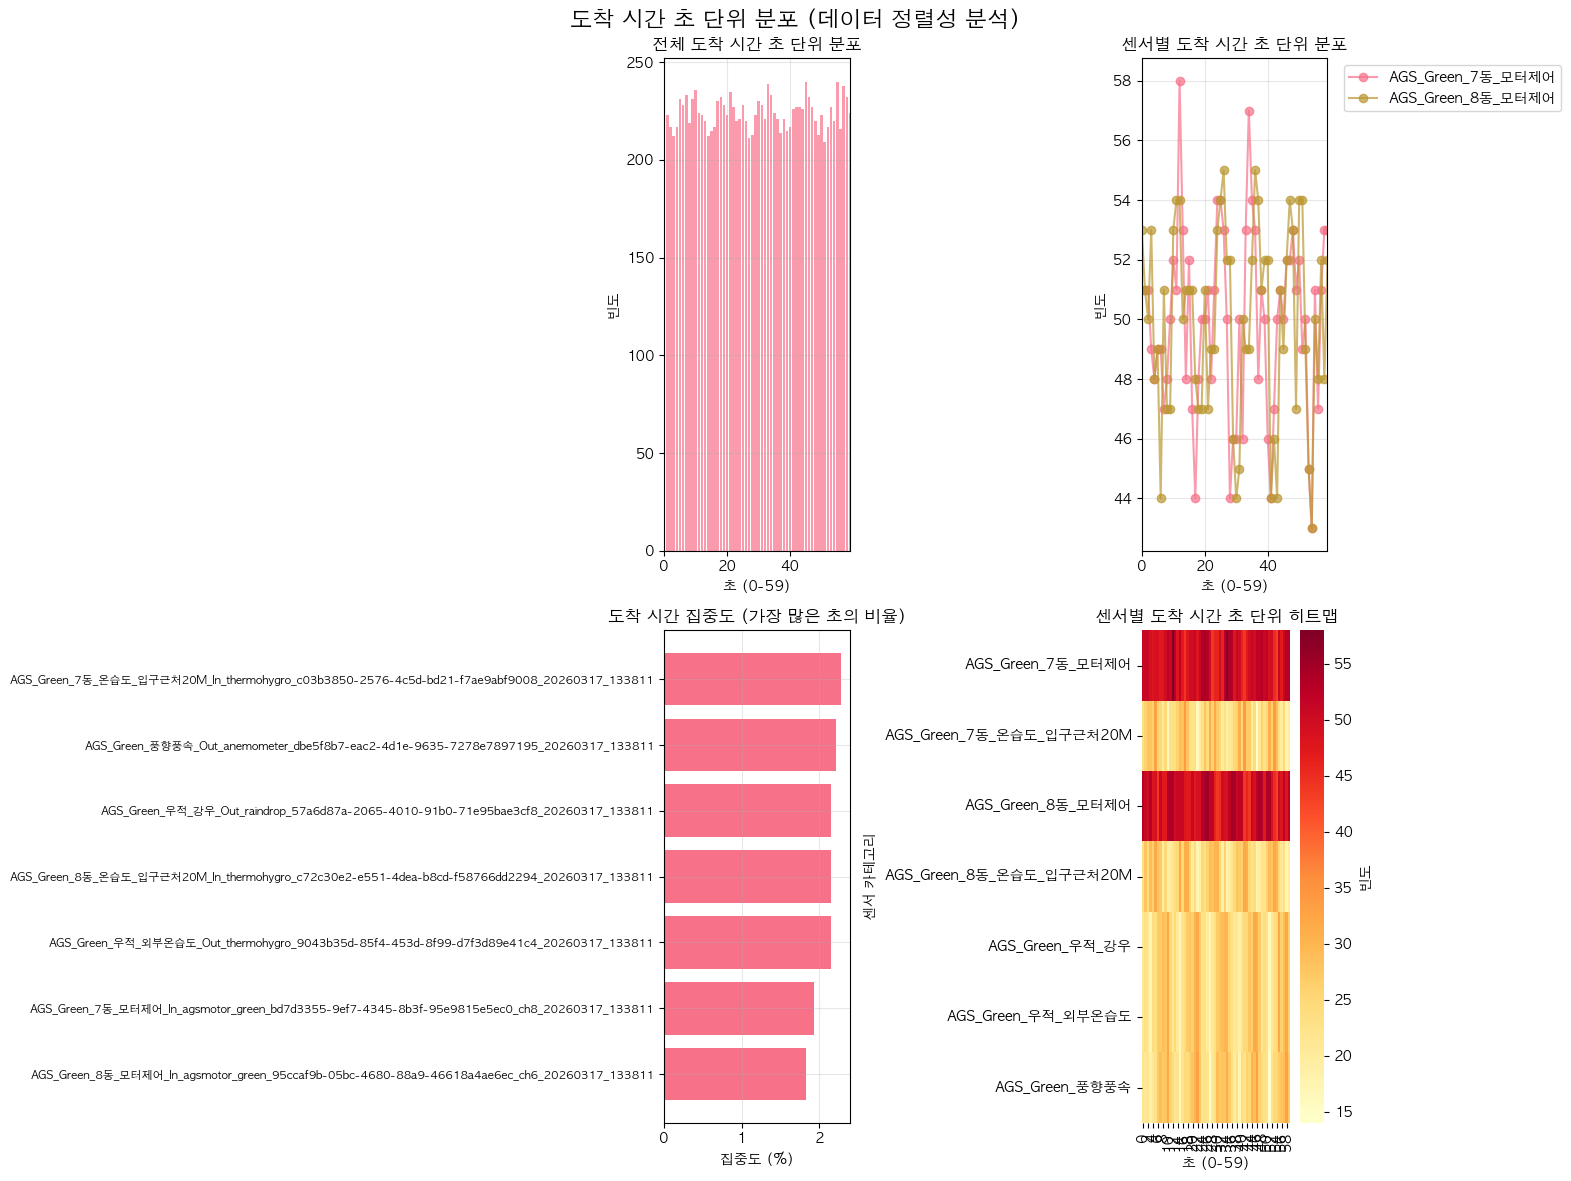

In [ ]:
# 동기화 품질 결과 요약
print("=== 동기화 품질 평가 결과 ===")
print(f"\n총 평가된 센서 파일: {len(sync_quality_df)}개")

# 센서 카테고리별 평균 품질
category_quality = sync_quality_df.groupby('sensor_category').agg({
    'interval_regularity': 'mean',
    'second_alignment': 'mean',
    'data_points': 'sum',
    'missing_rate': 'mean'
}).round(3)

print("\n센서 카테고리별 동기화 품질:")
print(category_quality.sort_values('interval_regularity'))

# 품질 등급 분류
def classify_quality(row):
    if row['interval_regularity'] < 0.2 and row['second_alignment'] < 15:
        return '우수'
    elif row['interval_regularity'] < 0.5 and row['second_alignment'] < 25:
        return '양호'
    elif row['interval_regularity'] < 1.0 and row['second_alignment'] < 35:
        return '보통'
    else:
        return '개선필요'

sync_quality_df['quality_grade'] = sync_quality_df.apply(classify_quality, axis=1)

print("\n품질 등급 분포:")
print(sync_quality_df['quality_grade'].value_counts())

# 동기화 품질 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('데이터 동기화 품질 평가', fontsize=16, fontweight='bold')

# 1. 도착 주기 규칙성 (변동계수)
regularity_avg = sync_quality_df.groupby('sensor_category')['interval_regularity'].mean().sort_values()
axes[0,0].barh(range(len(regularity_avg)), regularity_avg.values, color='green', alpha=0.7)
axes[0,0].set_title('센서별 도착 주기 규칙성 (변동계수)')
axes[0,0].set_xlabel('변동계수 (낮을수록 규칙적)')
axes[0,0].set_yticks(range(len(regularity_avg)))
axes[0,0].set_yticklabels([cat.replace('AGS_Green_', '') for cat in regularity_avg.index])
axes[0,0].grid(True, alpha=0.3)

# 2. 초 단위 정렬성
alignment_avg = sync_quality_df.groupby('sensor_category')['second_alignment'].mean().sort_values()
axes[0,1].barh(range(len(alignment_avg)), alignment_avg.values, color='purple', alpha=0.7)
axes[0,1].set_title('센서별 초 단위 정렬성')
axes[0,1].set_xlabel('표준편차 (낮을수록 정렬됨)')
axes[0,1].set_yticks(range(len(alignment_avg)))
axes[0,1].set_yticklabels([cat.replace('AGS_Green_', '') for cat in alignment_avg.index])
axes[0,1].grid(True, alpha=0.3)

# 3. 품질 등급 분포
grade_counts = sync_quality_df['quality_grade'].value_counts()
colors = ['gold', 'lightgreen', 'orange', 'red']
axes[1,0].pie(grade_counts.values, labels=grade_counts.index, autopct='%1.1f%%', colors=colors)
axes[1,0].set_title('동기화 품질 등급 분포')

# 4. 산점도: 규칙성 vs 정렬성
grade_colors = {'우수': 'gold', '양호': 'lightgreen', '보통': 'orange', '개선필요': 'red'}
for grade in sync_quality_df['quality_grade'].unique():
    grade_data = sync_quality_df[sync_quality_df['quality_grade'] == grade]
    axes[1,1].scatter(grade_data['interval_regularity'], grade_data['second_alignment'], 
                      c=grade_colors[grade], label=grade, alpha=0.7, s=50)

axes[1,1].set_xlabel('도착 주기 변동계수')
axes[1,1].set_ylabel('초 단위 정렬성 (표준편차)')
axes[1,1].set_title('동기화 품질 상관관계')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

# 이상 구역 표시
axes[1,1].axhline(y=20, color='red', linestyle='--', alpha=0.5, label='정렬성 기준')
axes[1,1].axvline(x=0.5, color='blue', linestyle='--', alpha=0.5, label='규칙성 기준')

plt.tight_layout()
plt.show()

## 최종 분석 요약 및 인사이트

In [ ]:
# 종합 분석 보고서
print("="*80)
print("SDF 데이터 도착 주기 및 동기화 품질 분석 보고서")
print("="*80)

print(f"\n📊 분석 대상:")
print(f"  - 센서 카테고리: {len(all_sensor_data)}개")
print(f"  - 전체 데이터 파일: {total_files}개")
print(f"  - 총 데이터 포인트: {total_data_points:,}개")
print(f"  - 분석 기간: {start_date.strftime('%Y-%m-%d')} ~ {end_date.strftime('%Y-%m-%d')}")

print(f"\n🕐 도착 주기 분석:")
print(f"  - 전체 평균 도착 주기: {avg_interval:.2f}초")
print(f"  - 전체 중앙값 도착 주기: {median_interval:.2f}초")
print(f"  - 전체 표준편차: {std_interval:.2f}초")
print(f"  - 최소 도착 주기: {min_interval:.2f}초")
print(f"  - 최대 도착 주기: {max_interval:.2f}초")

print(f"\n📈 센서 타입별 특징:")
print(f"  모터 센서:")
for sensor in motor_sensors:
    if sensor in avg_intervals_by_category:
        avg = avg_intervals_by_category[sensor]
        std = std_intervals_by_category[sensor]
        print(f"    - {sensor.replace('AGS_Green_', '')}: {avg:.2f}±{std:.2f}초")

print(f"  환경 센서:")
for sensor in env_sensors:
    if sensor in avg_intervals_by_category:
        avg = avg_intervals_by_category[sensor]
        std = std_intervals_by_category[sensor]
        print(f"    - {sensor.replace('AGS_Green_', '')}: {avg:.2f}±{std:.2f}초")

print(f"\n🎯 동기화 품질 평가:")
best_sync = category_quality.sort_values('interval_regularity').iloc[0]
worst_sync = category_quality.sort_values('interval_regularity').iloc[-1]

print(f"  - 최고 동기화 품질: {best_sync.name.replace('AGS_Green_', '')} (변동계수: {best_sync['interval_regularity']:.3f})")
print(f"  - 최저 동기화 품질: {worst_sync.name.replace('AGS_Green_', '')} (변동계수: {worst_sync['interval_regularity']:.3f})")

print(f"\n📊 품질 등급 분포:")
for grade, count in sync_quality_df['quality_grade'].value_counts().items():
    percentage = count / len(sync_quality_df) * 100
    print(f"  - {grade}: {count}개 ({percentage:.1f}%)")

print(f"\n⚠️  주요 발견사항:")
# 가장 높은 집중도를 가진 센서 찾기
highest_concentration = concentration_df.loc[concentration_df['concentration'].idxmax()]
print(f"  - 가장 높은 시간 정렬성: {highest_concentration['sensor_file']} (집중도: {highest_concentration['concentration']:.1f}%)")

# 가장 불규칙한 도착 주기를 가진 센서 찾기
most_irregular = sync_quality_df.loc[sync_quality_df['interval_regularity'].idxmax()]
print(f"  - 가장 불규칙한 도착 주기: {most_irregular['sensor_file']} (변동계수: {most_irregular['interval_regularity']:.3f})")

# 데이터 손실률이 높은 센서 찾기
highest_missing = sync_quality_df.loc[sync_quality_df['missing_rate'].idxmax()]
print(f"  - 가장 높은 데이터 손실률: {highest_missing['sensor_file']} ({highest_missing['missing_rate']:.1%})")

print(f"\n💡 개선 권고사항:")
print(f"  1. 동기화 품질이 '개선필요' 등급인 센서들의 데이터 수집 주기 검토")
print(f"  2. 초 단위 정렬성이 낮은 센서들의 타임스탬프 생성 로직 점검")
print(f"  3. 데이터 손실률이 높은 센서들의 네트워크 연결 상태 확인")
print(f"  4. 모터 센서와 환경 센서 간의 도착 주기 차이에 따른 데이터 처리 전략 수립")

print("\n" + "="*80)

🚀 5개 시간 윈도우로 분석 시작 (7일 데이터)...


시간 윈도우 분석:   0%|          | 0/5 [00:00<?, ?it/s]

  📈 1초 윈도우 분석 중...
📊 센서 타임스탬프 수집 중...


센서 데이터 처리: 100%|██████████| 7/7 [00:00<00:00, 449.90it/s]


📈 총 13,430개 데이터 포인트 분석
🔄 21개 센서 쌍 분석 중 (시간 윈도우: 1초)...


...

  📈 30초 윈도우 분석 중...
📊 센서 타임스탬프 수집 중...


센서 데이터 처리: 100%|██████████| 7/7 [00:00<00:00, 679.81it/s]


📈 총 13,430개 데이터 포인트 분석
🔄 21개 센서 쌍 분석 중 (시간 윈도우: 30초)...


시간 윈도우 분석: 100%|██████████| 5/5 [07:47<00:00, 93.58s/it]

✅ 센서 간 동시 도착 비율 분석 완료!


In [49]:
# 동시 도착 비율 결과 요약
print("=== 센서 간 동시 도착 비율 분석 결과 ===\n")

for window, results in all_alignment_results.items():
    print(f"📊 시간 윈도우: {window}")
    
    if not results:
        print("  분석 결과 없음")
        continue
    
    # 평균 동시 도착 비율 계산
    exact_ratios = [r['avg_exact_ratio'] for r in results.values()]
    window_ratios = [r['avg_window_ratio'] for r in results.values()]
    
    print(f"  평균 정확 동시 도착 비율: {np.mean(exact_ratios):.2f}%")
    print(f"  평균 윈도우 내 동시 도착 비율: {np.mean(window_ratios):.2f}%")
    
    # 최고/최저 동기화 쌍
    best_pair = max(results.items(), key=lambda x: x[1]['avg_window_ratio'])
    worst_pair = min(results.items(), key=lambda x: x[1]['avg_window_ratio'])
    
    print(f"  최고 동기화 쌍: {best_pair[0]}... ({best_pair[1]['avg_window_ratio']:.2f}%)")
    print(f"  최저 동기화 쌍: {worst_pair[0]}... ({worst_pair[1]['avg_window_ratio']:.2f}%)")
    print()
    sorted_list = sorted(results.items(), key=lambda x: x[1]['avg_window_ratio'])
    for el in sorted_list:
        print(el[0], el[1]['avg_window_ratio'])

=== 센서 간 동시 도착 비율 분석 결과 ===

📊 시간 윈도우: 1sec
  평균 정확 동시 도착 비율: 17.14%
  평균 윈도우 내 동시 도착 비율: 26.53%
  최고 동기화 쌍: AGS_Green_우적_외부온습도_Out_thermohygro_UUID_000008_20260317_133811 vs AGS_Green_풍향풍속_Out_anemometer_UUID_000004_20260317_133811... (100.00%)
  최저 동기화 쌍: AGS_Green_우적_외부온습도_Out_thermohygro_UUID_000008_20260317_133811 vs AGS_Green_8동_온습도_입구근처20M_In_thermohygro_UUID_000007_20260317_133811... (0.00%)

AGS_Green_우적_외부온습도_Out_thermohygro_UUID_000008_20260317_133811 vs AGS_Green_8동_온습도_입구근처20M_In_thermohygro_UUID_000007_20260317_133811 0.0
AGS_Green_우적_외부온습도_Out_thermohygro_UUID_000008_20260317_133811 vs AGS_Green_7동_온습도_입구근처20M_In_thermohygro_UUID_000001_20260317_133811 0.0
AGS_Green_풍향풍속_Out_anemometer_UUID_000004_20260317_133811 vs AGS_Green_8동_온습도_입구근처20M_In_thermohygro_UUID_000007_20260317_133811 0.0
AGS_Green_풍향풍속_Out_anemometer_UUID_000004_20260317_133811 vs AGS_Green_7동_온습도_입구근처20M_In_thermohygro_UUID_000001_20260317_133811 0.0
AGS_Green_8동_온습도_입구근처20M_In_thermohygro_UUID_000007_20

센서 카테고리별 도착 주기 통계:


,데이터수,평균,표준편차,최소,최대,중앙값,최빈값,25%,75%,1%
sensor_category,,,,,,,,,,
AGS_Green,13423,74.6,24.1,34.8,119.1,96.1,96.1,47.8,96.1,47.8


Category: AGS_Green, Type: <class 'pandas.core.series.Series'>, Shape: (13423,)


AttributeError: 'numpy.ndarray' object has no attribute 'hist'

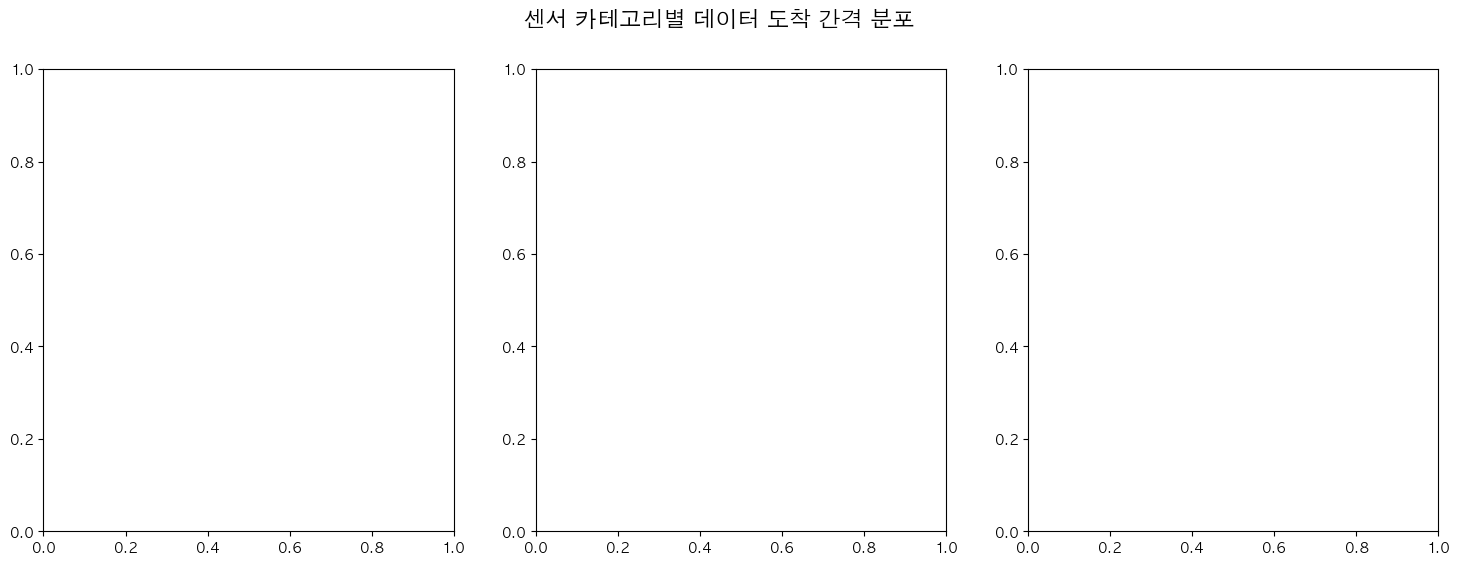

In [63]:
# 구간 값 분포도 시각화 (카테고리별 개별 시각화)
def plot_interval_distribution_by_category(all_sensor_data):
    """센서 데이터 구간 값 분포도 시각화 (카테고리별)"""
    
    # 모든 센서의 간격 데이터 수집
    intervals_data = []
    
    for sensor_name, sensor_data in all_sensor_data.items():
        for file_key, df in sensor_data.items():
            if 'timestamp' in df.columns and len(df) > 1:
                # 시간 간격 계산
                df_sorted = df.sort_values('timestamp')
                df_sorted['interval_seconds'] = df_sorted['timestamp'].diff().dt.total_seconds()
                
                # 결측치 제외
                intervals = df_sorted['interval_seconds'].dropna()
                
                # 센서 카테고리 추출
                category = sensor_name.split('_')[0] + '_' + sensor_name.split('_')[1]
                
                for interval in intervals:
                    intervals_data.append({
                        'sensor_category': category,
                        'sensor_name': sensor_name,
                        'file_key': file_key,
                        'interval_seconds': interval
                    })
    
    intervals_df = pd.DataFrame(intervals_data)
    
    if intervals_df.empty:
        print("❌ 분석할 간격 데이터가 없습니다.")
        return None, None
    
    # 한글 폰트 설정
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['axes.unicode_minus'] = False
    
    # 센서 카테고리별 통계 계산
    category_stats = intervals_df.groupby('sensor_category')['interval_seconds'].agg([
        'count', 'mean', 'std', 'min', 'max', 'median', 
        lambda x: x.mode().iloc[0] if not x.mode().empty else None,
        lambda x: x.quantile(0.25),
        lambda x: x.quantile(0.75),
        lambda x: x.quantile(0.01),
    ]).round(1)
    
    category_stats.columns = ['데이터수', '평균', '표준편차', '최소', '최대', '중앙값', '최빈값', '25%', '75%', '1%']
    category_stats = category_stats.sort_values('평균')
    
    print("센서 카테고리별 도착 주기 통계:")
    display(category_stats)
    
    # 카테고리별 개별 시각화
    categories = intervals_df['sensor_category'].unique()
    n_categories = len(categories)
    
    # 카테고리별로 2x3 그리드 생성 (카테고리 수에 따라 조정)
    rows = (n_categories + 2) // 3  # 3열로 배치
    fig, axes = plt.subplots(rows, 3, figsize=(18, 6*rows))
    fig.suptitle('센서 카테고리별 데이터 도착 간격 분포', fontsize=16, fontweight='bold')
    
    # axes가 1차원 배열일 경우 2차원으로 변환
    if rows == 1:
        axes = axes.reshape(1, -1)
    
    for i, category in enumerate(categories):
        row = i // 3
        col = i % 3
        
        if rows == 1:
            ax = axes[col]
        else:
            ax = axes[row, col]
        
        # 해당 카테고리 데이터 필터링 - 명확하게 Series로 변환
        category_series = intervals_df[intervals_df['sensor_category'] == category]['interval_seconds']
        
        # 디버깅: 타입 확인
        print(f"Category: {category}, Type: {type(category_series)}, Shape: {category_series.shape if hasattr(category_series, 'shape') else 'N/A'}")
        
        # 히스토그램 그리기
        ax.hist(category_series.values, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
        
        # 통계 정보 추가
        mean_val = category_series.mean()
        median_val = category_series.median()
        
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'평균: {mean_val:.1f}s')
        ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'중앙값: {median_val:.1f}s')
        
        # 제목과 레이블
        ax.set_title(f'{category}\n(n={len(category_series):,})', fontweight='bold')
        ax.set_xlabel('간격 (초)')
        ax.set_ylabel('빈도')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # x축 범위 조정 (이상치 제외)
        q99 = category_series.quantile(0.99)
        ax.set_xlim(0, min(q99, category_series.max()))
    
    # 빈 서브플롯 숨기기
    for i in range(n_categories, rows * 3):
        row = i // 3
        col = i % 3
        if rows == 1:
            axes[col].set_visible(False)
        else:
            axes[row, col].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # 추가: 카테고리별 상세 통계 시각화
    fig2, axes2 = plt.subplots(2, 2, figsize=(16, 12))
    fig2.suptitle('센서 카테고리별 통계 비교', fontsize=16, fontweight='bold')
    
    # 1. 평균 간격 막대그래프
    ax1 = axes2[0, 0]
    mean_intervals = category_stats['평균']
    bars = ax1.bar(mean_intervals.index, mean_intervals.values, color='lightcoral')
    ax1.set_title('카테고리별 평균 간격')
    ax1.set_ylabel('평균 간격 (초)')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3)
    
    # 값 표시
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}s', ha='center', va='bottom')
    
    # 2. 표준편차 막대그래프
    ax2 = axes2[0, 1]
    std_intervals = category_stats['표준편차']
    bars = ax2.bar(std_intervals.index, std_intervals.values, color='lightgreen')
    ax2.set_title('카테고리별 표준편차')
    ax2.set_ylabel('표준편차 (초)')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3)
    
    # 3. 데이터 수 막대그래프
    ax3 = axes2[1, 0]
    count_intervals = category_stats['데이터수']
    bars = ax3.bar(count_intervals.index, count_intervals.values, color='lightblue')
    ax3.set_title('카테고리별 데이터 수')
    ax3.set_ylabel('데이터 수')
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(True, alpha=0.3)
    
    # 4. 평균 vs 표준편차 산점도
    ax4 = axes2[1, 1]
    ax4.scatter(category_stats['평균'], category_stats['표준편차'], 
               s=100, c=range(len(category_stats)), cmap='viridis', alpha=0.7)
    for i, cat in enumerate(category_stats.index):
        ax4.annotate(cat, (category_stats['평균'][i], category_stats['표준편차'][i]),
                    xytext=(5, 5), textcoords='offset points', fontsize=9)
    ax4.set_xlabel('평균 간격 (초)')
    ax4.set_ylabel('표준편차 (초)')
    ax4.set_title('평균 vs 표준편차')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return intervals_df, category_stats

# 시각화 실행
intervals_df, category_stats = plot_interval_distribution_by_category(all_sensor_data)

In [64]:
# 센서 카테고리별 동시 도착 비율 분석 (7일 데이터, 진행상황 표시)
def analyze_category_alignment(all_sensor_data, time_window_seconds=5):
    """센서 카테고리별 동시 도착 비율 분석 (7일 데이터 기반)"""
    
    # 카테고리별 타임스탬프 그룹화
    print("📂 카테고리별 타임스탬프 그룹화 중...")
    category_timestamps = {}
    
    for sensor_name, sensor_data in tqdm(all_sensor_data.items(), desc="카테고리 그룹화"):
        category = sensor_name.split('_')[0] + '_' + sensor_name.split('_')[1]  # AGS_Green_XXX 추출
        
        if category not in category_timestamps:
            category_timestamps[category] = []
        
        for file_key, df in sensor_data.items():
            if 'timestamp' in df.columns:
                timestamps = df['timestamp'].dt.floor('S').tolist()
                category_timestamps[category].extend(timestamps)
    
    # 각 카테고리의 데이터 포인트 수 표시
    print("📊 카테고리별 데이터 포인트 수:")
    for category, timestamps in category_timestamps.items():
        print(f"  {category}: {len(timestamps):,}개")
    
    # 카테고리별 동시 도착 분석
    categories = list(category_timestamps.keys())
    category_alignment = {}
    
    print(f"\n🔄 {len(categories)}개 카테고리 간 동시 도착 분석 중...")
    
    for i, cat1 in enumerate(tqdm(categories, desc="카테고리 쌍 분석")):
        for j, cat2 in enumerate(categories[i+1:], i+1):
            timestamps1 = set(category_timestamps[cat1])
            timestamps2 = set(category_timestamps[cat2])
            
            # 정확히 같은 시간
            exact_matches = len(timestamps1 & timestamps2)
            
            # 시간 윈도우 내
            window_matches = 0
            for ts1 in category_timestamps[cat1]:
                for ts2 in category_timestamps[cat2]:
                    if abs((ts1 - ts2).total_seconds()) <= time_window_seconds:
                        window_matches += 1
                        break
            
            # 비율 계산
            total1 = len(category_timestamps[cat1])
            total2 = len(category_timestamps[cat2])
            
            exact_ratio1 = (exact_matches / total1 * 100) if total1 > 0 else 0
            exact_ratio2 = (exact_matches / total2 * 100) if total2 > 0 else 0
            
            window_ratio1 = (window_matches / total1 * 100) if total1 > 0 else 0
            window_ratio2 = (window_matches / total2 * 100) if total2 > 0 else 0
            
            category_alignment[f"{cat1} vs {cat2}"] = {
                'category1': cat1,
                'category2': cat2,
                'exact_matches': exact_matches,
                'window_matches': window_matches,
                'exact_ratio1': exact_ratio1,
                'exact_ratio2': exact_ratio2,
                'window_ratio1': window_ratio1,
                'window_ratio2': window_ratio2,
                'avg_window_ratio': (window_ratio1 + window_ratio2) / 2,
                'total1': total1,
                'total2': total2
            }
    
    return category_alignment

# 카테고리별 분석 실행 (7일 데이터 기반)
print("🚀 카테고리별 동시 도착 비율 분석 시작 (7일 데이터)...")
category_alignment = analyze_category_alignment(all_sensor_data, 5)

print("✅ 카테고리별 동시 도착 비율 분석 완료!")

🚀 카테고리별 동시 도착 비율 분석 시작 (7일 데이터)...
📂 카테고리별 타임스탬프 그룹화 중...


카테고리 그룹화: 100%|██████████| 7/7 [00:00<00:00, 295.53it/s]


📊 카테고리별 데이터 포인트 수:
  AGS_Green: 13,430개

🔄 1개 카테고리 간 동시 도착 분석 중...


카테고리 쌍 분석: 100%|██████████| 1/1 [00:00<00:00, 12300.01it/s]

✅ 카테고리별 동시 도착 비율 분석 완료!


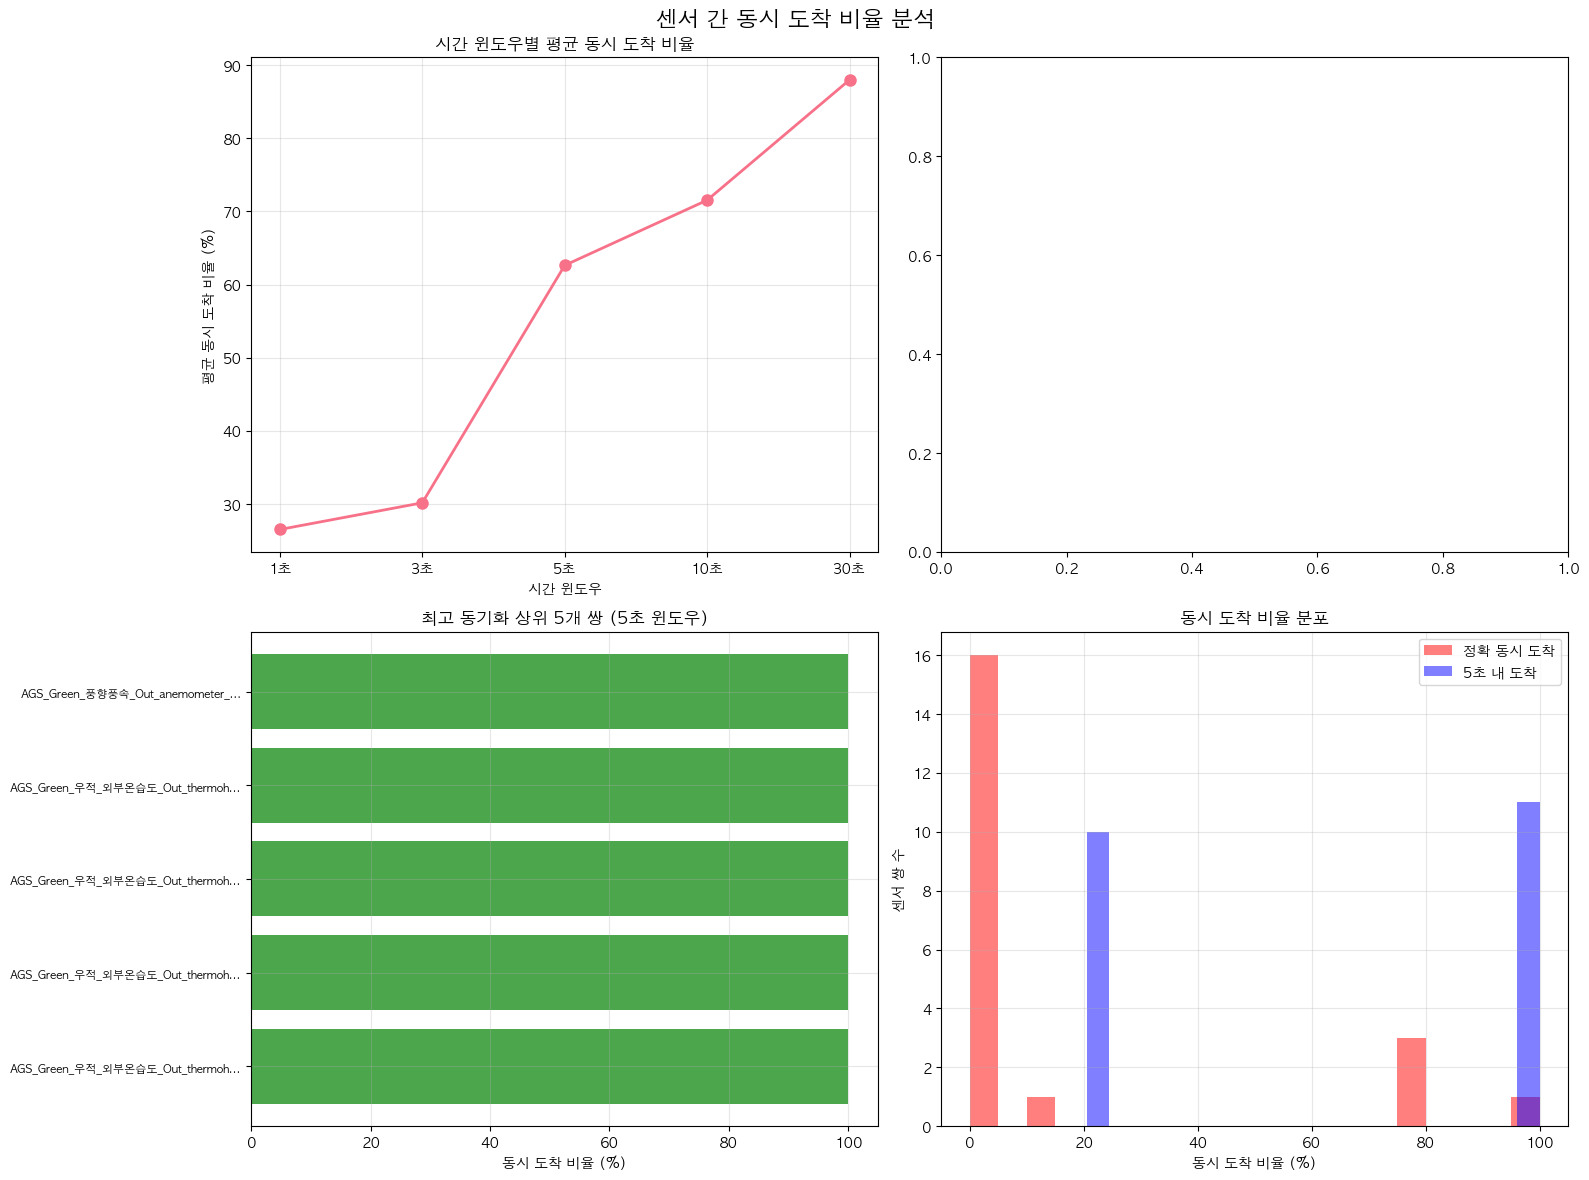

In [44]:
# 동시 도착 비율 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('센서 간 동시 도착 비율 분석', fontsize=16, fontweight='bold')

# 1. 시간 윈도우별 평균 동시 도착 비율
window_avg_ratios = []
window_labels = []

for window, results in all_alignment_results.items():
    if results:
        avg_ratio = np.mean([r['avg_window_ratio'] for r in results.values()])
        window_avg_ratios.append(avg_ratio)
        window_labels.append(window.replace('sec', '초'))

axes[0,0].plot(window_labels, window_avg_ratios, marker='o', linewidth=2, markersize=8)
axes[0,0].set_title('시간 윈도우별 평균 동시 도착 비율')
axes[0,0].set_xlabel('시간 윈도우')
axes[0,0].set_ylabel('평균 동시 도착 비율 (%)')
axes[0,0].grid(True, alpha=0.3)

# 2. 카테고리별 동시 도착 비율 히트맵
if category_alignment:
    categories = list(set([d['category1'] for d in category_alignment.values()] + 
                     [d['category2'] for d in category_alignment.values()]))
    
    heatmap_data = pd.DataFrame(index=categories, columns=categories, data=0)
    
    for pair_data in category_alignment.values():
        cat1, cat2 = pair_data['category1'], pair_data['category2']
        ratio = pair_data['avg_window_ratio']
        heatmap_data.loc[cat1, cat2] = ratio
        heatmap_data.loc[cat2, cat1] = ratio
    
    sns.heatmap(heatmap_data.astype(float), ax=axes[0,1], annot=True, fmt='.1f', 
                cmap='YlOrRd', cbar_kws={'label': '동시 도착 비율 (%)'})
    axes[0,1].set_title('카테고리별 동시 도착 비율 히트맵')
    axes[0,1].set_xlabel('센서 카테고리')
    axes[0,1].set_ylabel('센서 카테고리')

# 3. 최고/최저 동기화 쌍 비교 (5초 윈도우)
if '5sec' in all_alignment_results:
    results_5sec = all_alignment_results['5sec']
    if results_5sec:
        sorted_pairs = sorted(results_5sec.items(), key=lambda x: x[1]['avg_window_ratio'], reverse=True)
        
        top_5_pairs = sorted_pairs[:5]
        bottom_5_pairs = sorted_pairs[-5:]
        
        # 상위 5개
        top_labels = [pair[:30] + '...' for pair, _ in top_5_pairs]
        top_ratios = [data['avg_window_ratio'] for _, data in top_5_pairs]
        
        axes[1,0].barh(range(len(top_labels)), top_ratios, color='green', alpha=0.7)
        axes[1,0].set_yticks(range(len(top_labels)))
        axes[1,0].set_yticklabels(top_labels, fontsize=8)
        axes[1,0].set_xlabel('동시 도착 비율 (%)')
        axes[1,0].set_title('최고 동기화 상위 5개 쌍 (5초 윈도우)')
        axes[1,0].grid(True, alpha=0.3)

# 4. 동시 도착 데이터 분포
if '5sec' in all_alignment_results:
    results_5sec = all_alignment_results['5sec']
    if results_5sec:
        exact_ratios = [r['avg_exact_ratio'] for r in results_5sec.values()]
        window_ratios = [r['avg_window_ratio'] for r in results_5sec.values()]
        
        axes[1,1].hist(exact_ratios, bins=20, alpha=0.5, label='정확 동시 도착', color='red')
        axes[1,1].hist(window_ratios, bins=20, alpha=0.5, label='5초 내 도착', color='blue')
        axes[1,1].set_title('동시 도착 비율 분포')
        axes[1,1].set_xlabel('동시 도착 비율 (%)')
        axes[1,1].set_ylabel('센서 쌍 수')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# 정렬성 및 동기화 품질 분석
def analyze_alignment_quality(seconds_analysis):
    """데이터 정렬성 및 동기화 품질 분석"""
    alignment_metrics = {}
    
    for key, analysis in seconds_analysis.items():
        if not analysis:
            continue
            
        seconds_dist = analysis['seconds_distribution']
        total_points = analysis['total_points']
        
        # 정렬성 지표 계산
        # 1. 집중도 (가장 많은 초의 비율)
        concentration = analysis['concentration_ratio']
        
        # 2. 표준편차 (초 단위)
        std_second = analysis['std_second']
        
        # 3. 상위 3개 초에 집중된 데이터 비율
        top3_seconds = sorted(seconds_dist.items(), key=lambda x: x[1], reverse=True)[:3]
        top3_ratio = sum(count for _, count in top3_seconds) / total_points * 100
        
        # 4. 10초 이내에 도착하는 데이터 비율 (정렬성이 좋을수록 높음)
        aligned_10sec = sum(count for second, count in seconds_dist.items() if second <= 10) / total_points * 100
        
        # 5. 정렬성 점수 (종합 평가)
        alignment_score = (concentration * 0.4 + top3_ratio * 0.3 + aligned_10sec * 0.3)
        
        alignment_metrics[key] = {
            'concentration_ratio': concentration,
            'std_second': std_second,
            'top3_ratio': top3_ratio,
            'aligned_10sec_ratio': aligned_10sec,
            'alignment_score': alignment_score,
            'total_points': total_points
        }
    
    return alignment_metrics

alignment_metrics = analyze_alignment_quality(seconds_analysis)

# 정렬성 순위 표시
print("=== 데이터 정렬성 및 동기화 품질 분석 ===")
sorted_alignment = sorted(alignment_metrics.items(), key=lambda x: x[1]['alignment_score'], reverse=True)

for i, (key, metrics) in enumerate(sorted_alignment, 1):
    print(f"\n{i}. {key}")
    print(f"   정렬성 점수: {metrics['alignment_score']:.1f}/100")
    print(f"   집중도: {metrics['concentration_ratio']:.1f}%")
    print(f"   상위3초 집중도: {metrics['top3_ratio']:.1f}%")
    print(f"   10초 이내 정렬: {metrics['aligned_10sec_ratio']:.1f}%")
    print(f"   초 표준편차: {metrics['std_second']:.1f}초")

=== 데이터 정렬성 및 동기화 품질 분석 ===

1. AGS_Green_풍향풍속_Out_anemometer_UUID_000004_20260317_133811
   정렬성 점수: 7.9/100
   집중도: 1.8%
   상위3초 집중도: 5.4%
   10초 이내 정렬: 18.3%
   초 표준편차: 17.3초

2. AGS_Green_7동_온습도_입구근처20M_In_thermohygro_UUID_000001_20260317_133811
   정렬성 점수: 7.8/100
   집중도: 1.8%
   상위3초 집중도: 5.4%
   10초 이내 정렬: 18.4%
   초 표준편차: 17.3초

3. AGS_Green_우적_외부온습도_Out_thermohygro_UUID_000008_20260317_133811
   정렬성 점수: 7.8/100
   집중도: 1.8%
   상위3초 집중도: 5.4%
   10초 이내 정렬: 18.3%
   초 표준편차: 17.3초

4. AGS_Green_우적_강우_Out_raindrop_UUID_000009_20260317_133811
   정렬성 점수: 7.8/100
   집중도: 1.8%
   상위3초 집중도: 5.4%
   10초 이내 정렬: 18.3%
   초 표준편차: 17.3초

5. AGS_Green_8동_온습도_입구근처20M_In_thermohygro_UUID_000007_20260317_133811
   정렬성 점수: 7.8/100
   집중도: 1.8%
   상위3초 집중도: 5.3%
   10초 이내 정렬: 18.4%
   초 표준편차: 17.3초

6. AGS_Green_7동_모터제어_In_agsmotor_green_UUID_000003_ch8_20260317_133811
   정렬성 점수: 7.7/100
   집중도: 1.7%
   상위3초 집중도: 5.2%
   10초 이내 정렬: 18.3%
   초 표준편차: 17.3초

7. AGS_Green_7동_모터제어_In_agsmotor_green_UUID

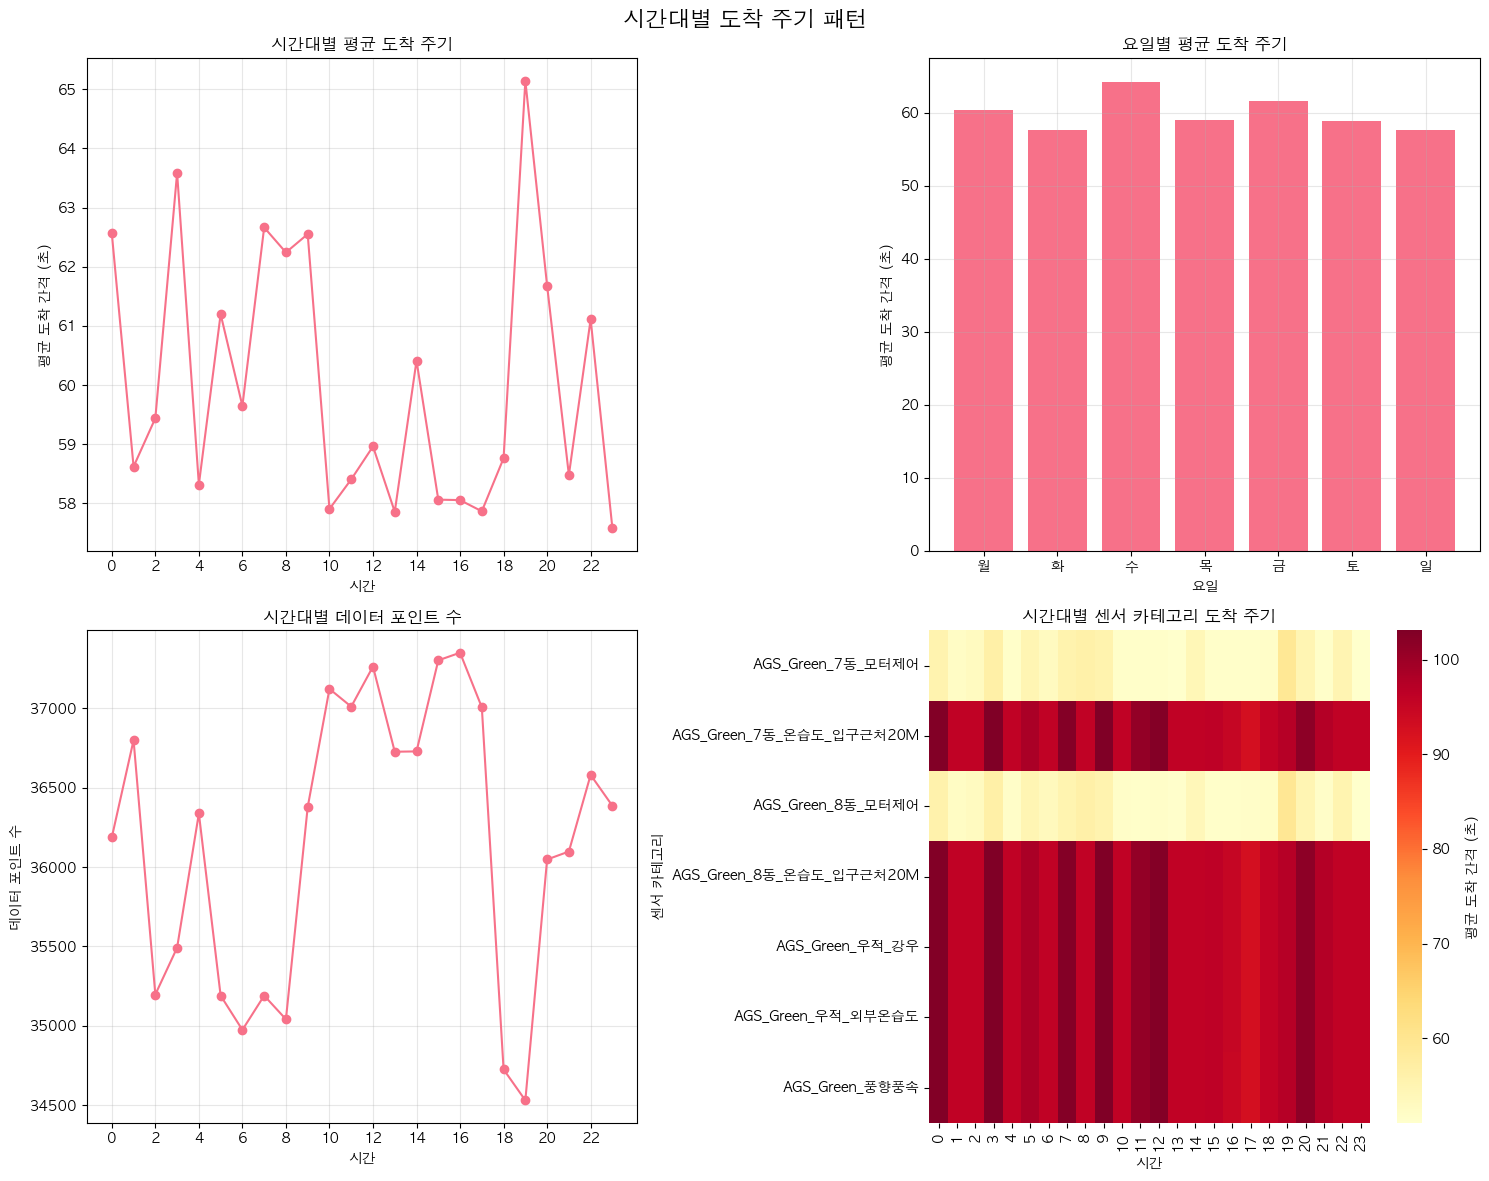

In [17]:
# 시간대별 도착 주기 패턴 시각화
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('시간대별 도착 주기 패턴', fontsize=16, fontweight='bold')

# 1. 시간대별 평균 도착 주기
hourly_avg = time_pattern_df.groupby('hour')['interval_seconds'].mean()
axes[0,0].plot(hourly_avg.index, hourly_avg.values, marker='o')
axes[0,0].set_title('시간대별 평균 도착 주기')
axes[0,0].set_xlabel('시간')
axes[0,0].set_ylabel('평균 도착 간격 (초)')
axes[0,0].grid(True, alpha=0.3)
axes[0,0].set_xticks(range(0, 24, 2))

# 2. 요일별 평균 도착 주기
dow_avg = time_pattern_df.groupby('day_of_week')['interval_seconds'].mean()
dow_labels = ['월', '화', '수', '목', '금', '토', '일']
axes[0,1].bar(dow_avg.index, dow_avg.values)
axes[0,1].set_title('요일별 평균 도착 주기')
axes[0,1].set_xlabel('요일')
axes[0,1].set_ylabel('평균 도착 간격 (초)')
axes[0,1].set_xticks(range(7))
axes[0,1].set_xticklabels(dow_labels)
axes[0,1].grid(True, alpha=0.3)

# 3. 시간대별 데이터 포인트 수
hourly_count = time_pattern_df.groupby('hour').size()
axes[1,0].plot(hourly_count.index, hourly_count.values, marker='o')
axes[1,0].set_title('시간대별 데이터 포인트 수')
axes[1,0].set_xlabel('시간')
axes[1,0].set_ylabel('데이터 포인트 수')
axes[1,0].grid(True, alpha=0.3)
axes[1,0].set_xticks(range(0, 24, 2))

# 4. 히트맵: 시간대 vs 센서 카테고리
heatmap_data = time_pattern_df.groupby(['hour', 'sensor_category'])['interval_seconds'].mean().unstack(fill_value=0)
sns.heatmap(heatmap_data.T, ax=axes[1,1], cmap='YlOrRd', cbar_kws={'label': '평균 도착 간격 (초)'})
axes[1,1].set_title('시간대별 센서 카테고리 도착 주기')
axes[1,1].set_xlabel('시간')
axes[1,1].set_ylabel('센서 카테고리')

plt.tight_layout()
plt.show()

## 이상치 및 특이 패턴 분석

In [18]:
# 이상치 탐지
def detect_outliers(intervals, threshold_factor=3.0):
    """IQR 방식으로 이상치 탐지"""
    if len(intervals) == 0:
        return []
    
    q25 = np.percentile(intervals, 25)
    q75 = np.percentile(intervals, 75)
    iqr = q75 - q25
    
    lower_bound = q25 - threshold_factor * iqr
    upper_bound = q75 + threshold_factor * iqr
    
    outliers = intervals[(intervals < lower_bound) | (intervals > upper_bound)]
    return outliers

# 각 센서별 이상치 분석
outlier_analysis = {}

for sensor_name, sensor_intervals in all_intervals.items():
    sensor_outliers = {}
    for file_key, intervals in sensor_intervals.items():
        outliers = detect_outliers(intervals)
        sensor_outliers[file_key] = {
            'total_intervals': len(intervals),
            'outlier_count': len(outliers),
            'outlier_percentage': len(outliers) / len(intervals) * 100 if len(intervals) > 0 else 0,
            'outliers': outliers.tolist()[:10]  # 처음 10개만 표시
        }
    outlier_analysis[sensor_name] = sensor_outliers

# 이상치 분석 결과 표시
print("이상치 분석 결과:")
for sensor_name, sensor_outliers in outlier_analysis.items():
    print(f"\n{sensor_name}:")
    for file_key, outlier_info in sensor_outliers.items():
        print(f"  {file_key}: {outlier_info['outlier_count']}/{outlier_info['total_intervals']} ({outlier_info['outlier_percentage']:.1f}%)")

이상치 분석 결과:

AGS_Green_우적_외부온습도:
  Out_thermohygro_UUID_000008_20260317_133811: 466/25568 (1.8%)

AGS_Green_풍향풍속:
  Out_anemometer_UUID_000004_20260317_133811: 466/25568 (1.8%)

AGS_Green_8동_온습도_입구근처20M:
  In_thermohygro_UUID_000007_20260317_133811: 466/25567 (1.8%)

AGS_Green_7동_온습도_입구근처20M:
  In_thermohygro_UUID_000001_20260317_133811: 466/25567 (1.8%)

AGS_Green_우적_강우:
  Out_raindrop_UUID_000009_20260317_133811: 466/25568 (1.8%)

AGS_Green_7동_모터제어:
  In_agsmotor_green_UUID_000003_ch8_20260317_133811: 9876/46276 (21.3%)
  In_agsmotor_green_UUID_000003_ch2_20260317_133811: 9876/46276 (21.3%)
  In_agsmotor_green_UUID_000003_ch7_20260317_133811: 9876/46276 (21.3%)
  In_agsmotor_green_UUID_000003_ch3_20260317_133811: 9876/46276 (21.3%)
  In_agsmotor_green_UUID_000003_ch6_20260317_133811: 9876/46276 (21.3%)
  In_agsmotor_green_UUID_000003_ch5_20260317_133811: 9876/46276 (21.3%)
  In_agsmotor_green_UUID_000003_ch4_20260317_133811: 9876/46276 (21.3%)
  In_agsmotor_green_UUID_000003_ch1_20260

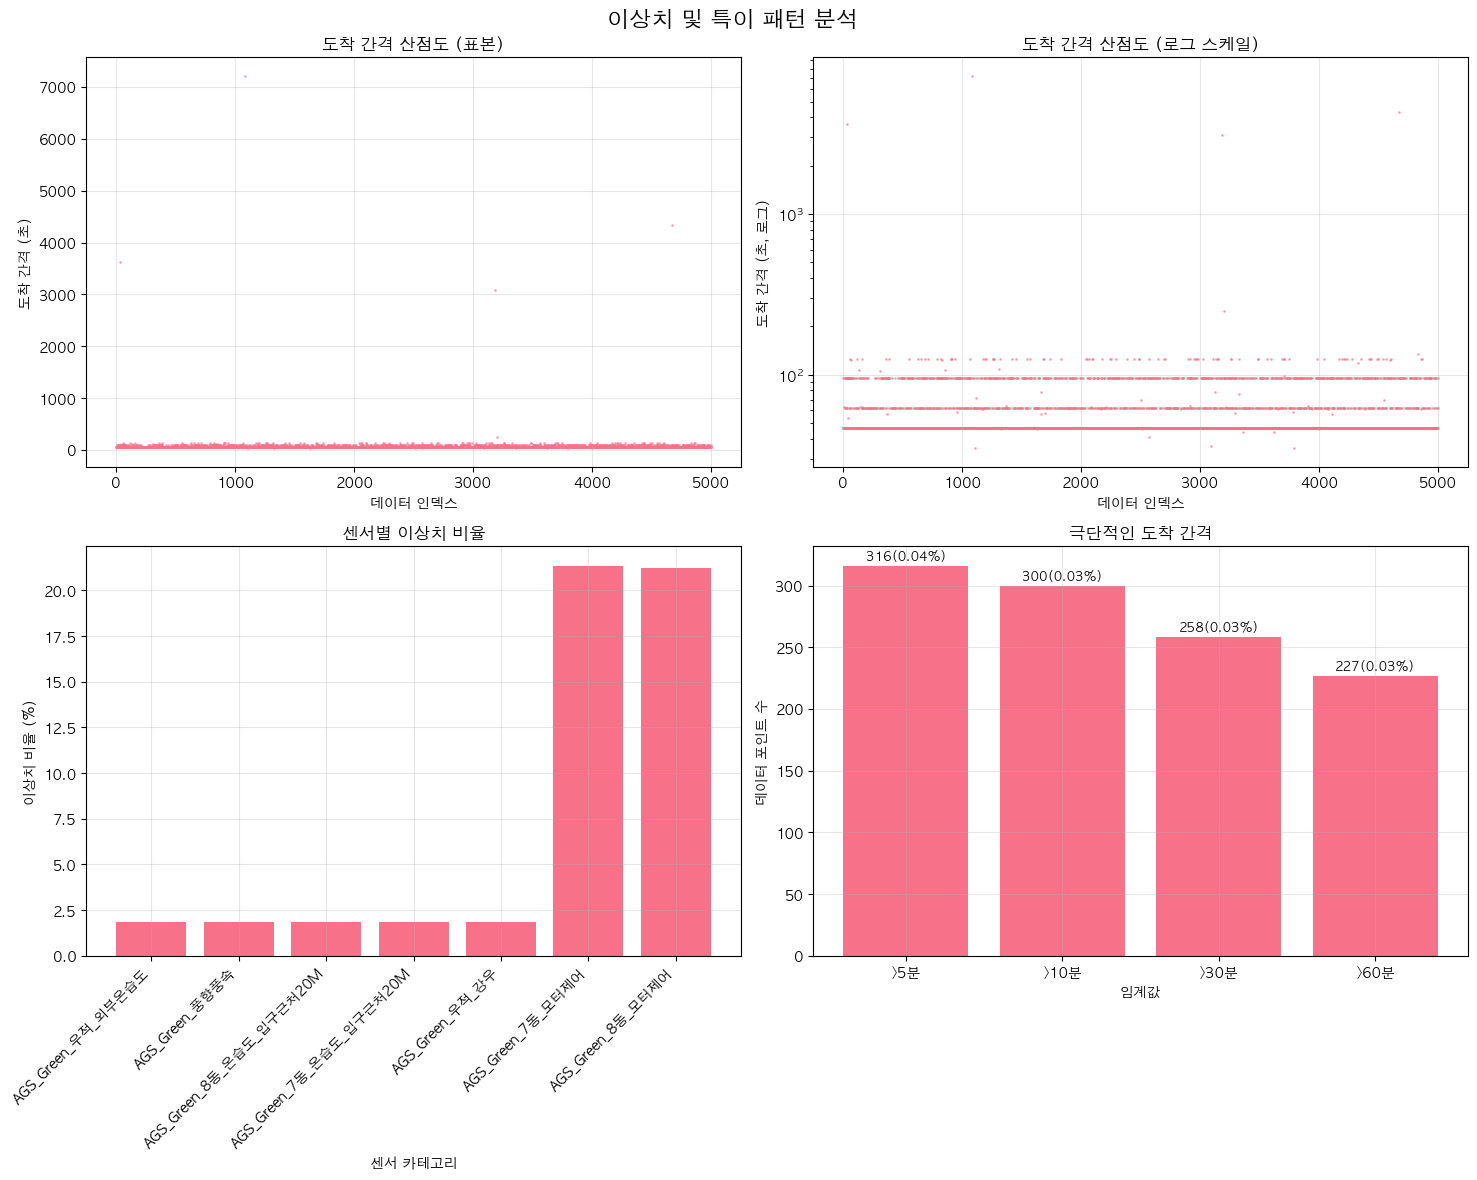

In [19]:
# 이상치 시각화
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('이상치 및 특이 패턴 분석', fontsize=16, fontweight='bold')

# 1. 전체 데이터의 이상치 산점도
sample_data = intervals_df.sample(min(5000, len(intervals_df)))  # 표본 추출
axes[0,0].scatter(range(len(sample_data)), sample_data['interval_seconds'], alpha=0.5, s=1)
axes[0,0].set_title('도착 간격 산점도 (표본)')
axes[0,0].set_xlabel('데이터 인덱스')
axes[0,0].set_ylabel('도착 간격 (초)')
axes[0,0].grid(True, alpha=0.3)

# 2. 로그 스케일 산점도
axes[0,1].scatter(range(len(sample_data)), sample_data['interval_seconds'], alpha=0.5, s=1)
axes[0,1].set_yscale('log')
axes[0,1].set_title('도착 간격 산점도 (로그 스케일)')
axes[0,1].set_xlabel('데이터 인덱스')
axes[0,1].set_ylabel('도착 간격 (초, 로그)')
axes[0,1].grid(True, alpha=0.3)

# 3. 센서별 이상치 비율
outlier_ratios = []
sensor_names = []

for sensor_name, sensor_outliers in outlier_analysis.items():
    total_intervals = sum(info['total_intervals'] for info in sensor_outliers.values())
    total_outliers = sum(info['outlier_count'] for info in sensor_outliers.values())
    ratio = total_outliers / total_intervals * 100 if total_intervals > 0 else 0
    outlier_ratios.append(ratio)
    sensor_names.append(sensor_name)

axes[1,0].bar(range(len(sensor_names)), outlier_ratios)
axes[1,0].set_title('센서별 이상치 비율')
axes[1,0].set_xlabel('센서 카테고리')
axes[1,0].set_ylabel('이상치 비율 (%)')
axes[1,0].set_xticks(range(len(sensor_names)))
axes[1,0].set_xticklabels(sensor_names, rotation=45, ha='right')
axes[1,0].grid(True, alpha=0.3)

# 4. 극단값 분석
extreme_thresholds = [300, 600, 1800, 3600]  # 5분, 10분, 30분, 1시간
extreme_counts = []
threshold_labels = []

for threshold in extreme_thresholds:
    count = (intervals_df['interval_seconds'] > threshold).sum()
    percentage = count / len(intervals_df) * 100
    extreme_counts.append(count)
    threshold_labels.append(f'>{threshold//60}분')

axes[1,1].bar(range(len(threshold_labels)), extreme_counts)
axes[1,1].set_title('극단적인 도착 간격')
axes[1,1].set_xlabel('임계값')
axes[1,1].set_ylabel('데이터 포인트 수')
axes[1,1].set_xticks(range(len(threshold_labels)))
axes[1,1].set_xticklabels(threshold_labels)
axes[1,1].grid(True, alpha=0.3)

# 값 표시
for i, count in enumerate(extreme_counts):
    axes[1,1].text(i, count + max(extreme_counts)*0.01, f'{count:,}({count/len(intervals_df)*100:.2f}%)', 
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 요약 및 결론

In [20]:
# 최종 요약 통계
summary_stats = {
    'total_data_points': len(intervals_df),
    'total_sensors': len(all_sensor_data),
    'overall_mean_interval': intervals_df['interval_seconds'].mean(),
    'overall_median_interval': intervals_df['interval_seconds'].median(),
    'overall_std_interval': intervals_df['interval_seconds'].std(),
    'min_interval': intervals_df['interval_seconds'].min(),
    'max_interval': intervals_df['interval_seconds'].max(),
    'extreme_delays_5min': (intervals_df['interval_seconds'] > 300).sum(),
    'extreme_delays_1hour': (intervals_df['interval_seconds'] > 3600).sum(),
}

print("=== 센서 데이터 도착 주기 분석 요약 ===")
print(f"총 데이터 포인트: {summary_stats['total_data_points']:,}")
print(f"분석된 센서 수: {summary_stats['total_sensors']}")
print(f"전체 평균 도착 간격: {summary_stats['overall_mean_interval']:.1f}초 ({summary_stats['overall_mean_interval']/60:.1f}분)")
print(f"전체 중앙값 도착 간격: {summary_stats['overall_median_interval']:.1f}초 ({summary_stats['overall_median_interval']/60:.1f}분)")
print(f"표준편차: {summary_stats['overall_std_interval']:.1f}초")
print(f"최소 간격: {summary_stats['min_interval']:.1f}초")
print(f"최대 간격: {summary_stats['max_interval']:.1f}초 ({summary_stats['max_interval']/3600:.1f}시간)")
print(f"5분 이상 지연: {summary_stats['extreme_delays_5min']:,}개 ({summary_stats['extreme_delays_5min']/summary_stats['total_data_points']*100:.2f}%)")
print(f"1시간 이상 지연: {summary_stats['extreme_delays_1hour']:,}개 ({summary_stats['extreme_delays_1hour']/summary_stats['total_data_points']*100:.2f}%)")

print("\n=== 센서별 특징 ===")
for sensor_name in intervals_df['sensor_category'].unique():
    sensor_data = intervals_df[intervals_df['sensor_category'] == sensor_name]
    mean_interval = sensor_data['interval_seconds'].mean()
    data_count = len(sensor_data)
    print(f"{sensor_name}: 평균 {mean_interval:.1f}초, 데이터 {data_count:,}개")

=== 센서 데이터 도착 주기 분석 요약 ===
총 데이터 포인트: 867,670
분석된 센서 수: 7
전체 평균 도착 간격: 60.0초 (1.0분)
전체 중앙값 도착 간격: 47.0초 (0.8분)
표준편차: 109.4초
최소 간격: 6.0초
최대 간격: 7229.0초 (2.0시간)
5분 이상 지연: 316개 (0.04%)
1시간 이상 지연: 227개 (0.03%)

=== 센서별 특징 ===
AGS_Green_우적_외부온습도: 평균 97.9초, 데이터 25,568개
AGS_Green_풍향풍속: 평균 97.9초, 데이터 25,568개
AGS_Green_8동_온습도_입구근처20M: 평균 97.9초, 데이터 25,567개
AGS_Green_7동_온습도_입구근처20M: 평균 97.9초, 데이터 25,567개
AGS_Green_우적_강우: 평균 97.9초, 데이터 25,568개
AGS_Green_7동_모터제어: 평균 53.4초, 데이터 370,208개
AGS_Green_8동_모터제어: 평균 53.5초, 데이터 369,624개
